# Test du modèle Qwen2.5-VL-7B-Instruct

**Objectif :** Vérifier que le modèle Qwen2.5-VL-7B-Instruct peut être chargé et utilisé correctement.

**Ce notebook teste :**
1. Le téléchargement et chargement du modèle depuis Hugging Face
2. La capacité du modèle à traiter des images
3. Les performances en termes de mémoire GPU et temps d'inférence
4. La qualité des réponses en français et anglais

**Prérequis :**
- GPU avec CUDA activé
- Au moins 20 GB de mémoire GPU disponible
- Connexion internet pour télécharger le modèle (~14-15 GB)

## 1. Imports et vérification de l'environnement

In [1]:
import torch
from transformers import AutoModelForVision2Seq, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image
import time
import os

print("=" * 60)
print("VÉRIFICATION ENVIRONNEMENT")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Mémoire GPU totale: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"Mémoire GPU disponible: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")
print("=" * 60)

VÉRIFICATION ENVIRONNEMENT
PyTorch version: 2.9.1+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5090
Mémoire GPU totale: 31.36 GB
Mémoire GPU disponible: 31.36 GB


## 2. Chargement du modèle Qwen2.5-VL-7B-Instruct

**Note importante :** Le premier chargement téléchargera le modèle (~14-15 GB), ce qui peut prendre plusieurs minutes selon votre connexion internet.

Le modèle sera mis en cache dans `~/.cache/huggingface/` pour les utilisations futures.

In [2]:
# Nom du modèle sur Hugging Face
model_name = "Qwen/Qwen2.5-VL-7B-Instruct"

print(f"\nChargement du modèle: {model_name}")
print("Cela peut prendre plusieurs minutes lors du premier téléchargement...\n")

# Mesurer le temps de chargement
start_time = time.time()

# Charger le modèle avec les paramètres optimaux
# - dtype="auto" : utilise le type optimal (bfloat16 ou float16)
# - device_map="auto" : place automatiquement le modèle sur GPU
model = AutoModelForVision2Seq.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto"
)

# Charger le processeur (tokenizer + image processor)
processor = AutoProcessor.from_pretrained(model_name)

load_time = time.time() - start_time

print(f"\n✓ Modèle chargé avec succès en {load_time:.2f} secondes")
print(f"✓ Nombre de paramètres: {model.num_parameters() / 1e9:.2f}B")
print(f"✓ Type de données: {model.dtype}")

# Vérifier l'utilisation de la mémoire GPU
if torch.cuda.is_available():
    memory_allocated = torch.cuda.memory_allocated(0) / 1024**3
    memory_reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"\nMémoire GPU utilisée:")
    print(f"  - Allouée: {memory_allocated:.2f} GB")
    print(f"  - Réservée: {memory_reserved:.2f} GB")


Chargement du modèle: Qwen/Qwen2.5-VL-7B-Instruct
Cela peut prendre plusieurs minutes lors du premier téléchargement...



/home/hounfodjidagba/miniconda3/envs/cassava/lib/python3.11/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.



✓ Modèle chargé avec succès en 7.02 secondes
✓ Nombre de paramètres: 8.29B
✓ Type de données: torch.bfloat16

Mémoire GPU utilisée:
  - Allouée: 15.45 GB
  - Réservée: 15.45 GB


## 3. Test avec une image simple

Nous allons créer une image de test simple et demander au modèle de la décrire.

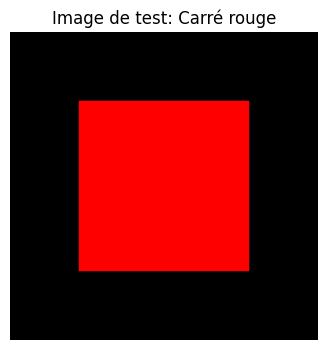

Image de test créée: carré rouge 224x224 pixels


In [3]:
# Créer une image de test simple (carré rouge)
import numpy as np

# Créer une image RGB 224x224 avec un carré rouge
test_image = np.zeros((224, 224, 3), dtype=np.uint8)
test_image[50:174, 50:174] = [255, 0, 0]  # Carré rouge au centre
test_image_pil = Image.fromarray(test_image)

# Afficher l'image
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.imshow(test_image_pil)
plt.title("Image de test: Carré rouge")
plt.axis('off')
plt.show()

print("Image de test créée: carré rouge 224x224 pixels")

## 4. Inférence avec le modèle

Testons le modèle avec une question simple en anglais, puis en français.

In [4]:
def run_inference(image, question, language="en"):
    """
    Exécute l'inférence avec le modèle Qwen2.5-VL
    
    Args:
        image: Image PIL
        question: Question à poser sur l'image
        language: Langue de la question ("en" ou "fr")
    
    Returns:
        str: Réponse du modèle
        float: Temps d'inférence en secondes
    """
    # Préparer le message selon le format Qwen2.5-VL
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {"type": "text", "text": question},
            ],
        }
    ]
    
    # Préparer les inputs pour le modèle
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("cuda")
    
    # Générer la réponse
    start_time = time.time()
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,  # Greedy decoding pour la cohérence
        )
    
    inference_time = time.time() - start_time
    
    # Décoder la réponse
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]
    
    return output_text, inference_time

### Test 1 : Question en anglais

In [5]:
question_en = "What do you see in this image? Describe it in detail."

print("=" * 60)
print("TEST 1: Question en anglais")
print("=" * 60)
print(f"Question: {question_en}\n")

response_en, time_en = run_inference(test_image_pil, question_en, "en")

print(f"Réponse: {response_en}")
print(f"\nTemps d'inférence: {time_en:.2f} secondes")
print("=" * 60)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEST 1: Question en anglais
Question: What do you see in this image? Describe it in detail.

Réponse: The image shows a single, solid red square. The square is evenly filled with a bright red color and has no gradients or variations in shade. It is centered within the frame of the image, and there are no other shapes, text, or additional elements present. The background is completely black, which contrasts sharply with the red square, making it stand out prominently. The square appears to be a simple geometric shape without any additional features such as lines, curves, or textures.

Temps d'inférence: 1.62 secondes


### Test 2 : Question en français

In [6]:
question_fr = "Que voyez-vous dans cette image ? Décrivez-la en détail."

print("=" * 60)
print("TEST 2: Question en français")
print("=" * 60)
print(f"Question: {question_fr}\n")

response_fr, time_fr = run_inference(test_image_pil, question_fr, "fr")

print(f"Réponse: {response_fr}")
print(f"\nTemps d'inférence: {time_fr:.2f} secondes")
print("=" * 60)

TEST 2: Question en français
Question: Que voyez-vous dans cette image ? Décrivez-la en détail.

Réponse: Cette image montre un carré de couleur rouge vif sur un fond noir. Le carré est parfaitement symétrique et occupe la majeure partie de l'image, ce qui suggère qu'il pourrait être utilisé comme un symbole ou une icône. Il n'y a pas d'autres éléments visibles dans l'image.

Temps d'inférence: 0.98 secondes


## 5. Statistiques finales

In [7]:
print("\n" + "=" * 60)
print("RÉSUMÉ DES TESTS")
print("=" * 60)
print(f"✓ Modèle: {model_name}")
print(f"✓ Nombre de paramètres: {model.num_parameters() / 1e9:.2f}B")
print(f"✓ Type de données: {model.dtype}")
print(f"\nPerformances:")
print(f"  - Temps de chargement: {load_time:.2f}s")
print(f"  - Temps d'inférence (EN): {time_en:.2f}s")
print(f"  - Temps d'inférence (FR): {time_fr:.2f}s")

if torch.cuda.is_available():
    memory_allocated = torch.cuda.memory_allocated(0) / 1024**3
    memory_reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"\nUtilisation mémoire GPU:")
    print(f"  - Mémoire allouée: {memory_allocated:.2f} GB")
    print(f"  - Mémoire réservée: {memory_reserved:.2f} GB")

print("\n✓ Le modèle Qwen2.5-VL-7B-Instruct fonctionne correctement!")
print("✓ Prêt pour les tests sur les images de manioc.")
print("=" * 60)


RÉSUMÉ DES TESTS
✓ Modèle: Qwen/Qwen2.5-VL-7B-Instruct
✓ Nombre de paramètres: 8.29B
✓ Type de données: torch.bfloat16

Performances:
  - Temps de chargement: 7.02s
  - Temps d'inférence (EN): 1.62s
  - Temps d'inférence (FR): 0.98s

Utilisation mémoire GPU:
  - Mémoire allouée: 15.45 GB
  - Mémoire réservée: 15.50 GB

✓ Le modèle Qwen2.5-VL-7B-Instruct fonctionne correctement!
✓ Prêt pour les tests sur les images de manioc.


## 6. Nettoyage de la mémoire (optionnel)

Si vous souhaitez libérer la mémoire GPU après les tests, exécutez la cellule suivante.

In [8]:
# Libérer la mémoire GPU
del model
del processor
torch.cuda.empty_cache()

print("✓ Mémoire GPU libérée")
if torch.cuda.is_available():
    print(f"Mémoire GPU disponible: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")

✓ Mémoire GPU libérée
Mémoire GPU disponible: 31.35 GB


## Conclusions

Ce notebook a permis de vérifier que :
1. ✅ Le modèle Qwen2.5-VL-7B-Instruct peut être téléchargé et chargé
2. ✅ Le modèle fonctionne sur votre GPU
3. ✅ Le modèle peut traiter des images et répondre en anglais et français
4. ✅ Les performances (temps, mémoire) sont acceptables

**Prochaines étapes :**
- Tester le modèle sur de vraies images de feuilles de manioc
- Évaluer ses capacités en classification zero-shot
- Commencer l'exploration des données (EDA)